# Bài tập 2.1.2 — Phân tích thống kê tập dữ liệu Plant Diseases

**Tập dữ liệu:** New Plant Diseases Dataset (Augmented)
**Mô tả:** ~87,000 ảnh RGB về lá cây khỏe mạnh và bị bệnh, phân thành 38 lớp
**Cấu trúc:** `train/` (80% ≈ 70,295 ảnh) và `valid/` (20% ≈ 17,572 ảnh), thư mục con theo tên lớp
**Nguồn:** [Kaggle — New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset)

---

## Mục tiêu

Phần này thực hiện **phân tích thống kê mô tả toàn diện (Comprehensive Descriptive Statistical Analysis)** trước khi tiền xử lý, gồm 4 nội dung bắt buộc:

| Câu | Nội dung |
|-----|----------|
| **a** | Phân phối giá trị pixel theo từng kênh màu (Histogram + KDE) |
| **b** | Phân tích mất cân bằng lớp (Class Imbalance) |
| **c** | Phát hiện ảnh trùng lặp bằng perceptual hash (pHash) |
| **d** | Phân tích độ sáng và độ tương phản theo lớp (Boxplot) |

---

## Chiến lược lấy mẫu (Sampling Strategy)

Do dataset có ~87,000 ảnh, việc load toàn bộ vào RAM đòi hỏi >1GB bộ nhớ và thời gian xử lý lớn. Notebook này sử dụng hai chế độ tùy theo yêu cầu từng câu:
> - `SAMPLE (N ảnh)` — kết quả là ước lượng thống kê
> - `TOÀN BỘ` — kết quả phản ánh đúng toàn bộ dataset

| Câu | Chế độ | Số ảnh | Lý do |
|-----|--------|--------|-------|
| **a** | **SAMPLE** | 50/lớp × 38 = **1,900 ảnh** | Phân tích phân phối pixel — 50 ảnh/lớp đủ để ước lượng phân phối theo Central Limit Theorem. Kết quả là **ước lượng thống kê**, không phải giá trị tuyệt đối |
| **b** | **TOÀN BỘ** | Đếm toàn bộ ~70,295 file | Đánh giá class imbalance đòi hỏi **con số tuyệt đối** — không thể dùng sample |
| **c** | **TOÀN BỘ** | Scan toàn bộ ~70,295 ảnh | Phát hiện duplicate bắt buộc phải so sánh tất cả ảnh — bỏ sót bất kỳ ảnh nào có thể bỏ lỡ data leakage |
| **d** | **SAMPLE** | 100/lớp × 38 = **3,800 ảnh** | Ước lượng mean/std per-class — 100 ảnh/lớp cho sai số chuẩn SE = std/√100 ≈ 0.5 đơn vị, chấp nhận được |

---
## Cài đặt thư viện & Cấu hình

In [ ]:
%pip install numpy pandas matplotlib seaborn imagehash opencv-python scipy tqdm pillow kagglehub -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LOQ\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import imagehash
import cv2
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Cấu hình style biểu đồ ───────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

# ── Đường dẫn dataset ────────────────────────────────────────
BASE_DIR  = Path(path) / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = BASE_DIR / "train"
VALID_DIR = BASE_DIR / "valid"

assert TRAIN_DIR.exists(), f"Không tìm thấy: {TRAIN_DIR}"
assert VALID_DIR.exists(), f"Không tìm thấy: {VALID_DIR}"

# ── Đường dẫn các biểu đồ ────────────────────────────────────────
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Lấy danh sách tất cả các lớp ─────────────────────────────
CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"Tổng số lớp      : {len(CLASSES)}")
print(f"Một vài lớp mẫu  : {CLASSES[:4]} ...")
print(f"TRAIN_DIR        : {TRAIN_DIR}")
print(f"OUTPUT_DIR        : {OUTPUT_DIR}")

Tổng số lớp      : 38
Một vài lớp mẫu  : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy'] ...
TRAIN_DIR        : C:\Users\LOQ\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
OUTPUT_DIR        : figures


### Hàm tiện ích — Load ảnh cho sample

**Tại sao cần shuffle ngẫu nhiên thay vì lấy N ảnh đầu tiên?**

Hàm `glob("*.jpg")` trả về file theo **thứ tự hệ thống file** (phụ thuộc OS và filesystem), không ngẫu nhiên. Trong dataset PlantVillage augmented, các file được đặt tên theo pattern augmentation (`_flipLR`, `_newGGR`, v.v.) — nếu không shuffle, 50 ảnh đầu tiên có thể là cùng một loại augmentation, gây **thiên lệch (bias) trong phân tích**. `seed=42` đảm bảo **tái tạo được (reproducible)**.

**Tại sao 50 ảnh/lớp đủ cho phân tích pixel?** Theo Central Limit Theorem, với n=50 ảnh/lớp, ước lượng mean pixel có sai số chuẩn SE ≈ std/√(n × H × W) — với ảnh 64×64, mỗi kênh có 50 × 4,096 = 204,800 pixel mẫu → SE cực nhỏ, đủ để ước lượng phân phối chính xác.

In [ ]:
def load_sample_per_class(base_dir, max_per_class=50, size=(64, 64), seed=42):
    """
    Load MẪU (SAMPLE) ảnh từ tất cả các lớp trong base_dir.

    ĐÂY LÀ HÀM LẤY MẪU — không load toàn bộ dataset.
    Kết quả thống kê là ước lượng (estimate), không phải giá trị chính xác tuyệt đối.

    Parameters:
    -----------
    max_per_class : int  — số ảnh tối đa mỗi lớp (default 50)
    size          : tuple — resize về (W, H) trước khi load (default 64×64)
    seed          : int  — random seed để đảm bảo reproducibility

    Returns: (images: ndarray (N,H,W,3), labels: ndarray (N,), paths: list[str])
    """
    rng = np.random.default_rng(seed)
    all_images, all_labels, all_paths = [], [], []

    for cls in tqdm(CLASSES, desc=f"SAMPLE load ({max_per_class} ảnh/lớp)"):
        cls_dir   = Path(base_dir) / cls
        all_files = list(cls_dir.glob("*.jpg"))
        # Shuffle ngẫu nhiên → tránh thiên lệch theo tên file / augmentation type
        idx_sel   = rng.choice(len(all_files), min(max_per_class, len(all_files)), replace=False)
        selected  = [all_files[i] for i in idx_sel]

        for img_path in selected:
            try:
                img = Image.open(img_path).convert("RGB").resize(size)
                all_images.append(np.array(img))
                all_labels.append(cls)
                all_paths.append(str(img_path))
            except Exception:
                pass

    return np.array(all_images), np.array(all_labels), all_paths


# ── Load sample cho Câu a (phân tích pixel) ──────────────────
# SAMPLE MODE: 50 ảnh/lớp × 38 lớp = 1,900 ảnh (2.2% của ~87K)
print("  SAMPLE MODE — Câu a: Load 50 ảnh/lớp × 38 lớp")
images, labels, img_paths = load_sample_per_class(TRAIN_DIR, max_per_class=50, size=(64,64))
print(f"\nTổng ảnh đã load (sample) : {images.shape[0]:,} / ~70,295 train ({images.shape[0]/70295*100:.1f}%)")
print(f"Shape mỗi ảnh              : {images.shape[1:]}  (H × W × C)")
print(f"Bộ nhớ sử dụng             : {images.nbytes / 1024**2:.1f} MB")
print(f"Seed                        : 42")

  SAMPLE MODE — Câu a: Load 50 ảnh/lớp × 38 lớp


SAMPLE load (50 ảnh/lớp): 100%|████████████████████████████████████████████████████████| 38/38 [00:10<00:00,  3.77it/s]


Tổng ảnh đã load (sample) : 1,900 / ~70,295 train (2.7%)
Shape mỗi ảnh              : (64, 64, 3)  (H × W × C)
Bộ nhớ sử dụng             : 22.3 MB
Seed                        : 42


---
## Câu a) Phân phối giá trị pixel theo từng kênh màu

### Lý thuyết

Mỗi ảnh RGB gồm 3 kênh màu độc lập: **Red (R)**, **Green (G)**, **Blue (B)**. Giá trị mỗi pixel nằm trong khoảng **[0, 255]** (kiểu dữ liệu `uint8`).

**Tại sao phân tích phân phối pixel trước khi tiền xử lý?**

Đây là bước nền tảng vì nó trả lời 5 câu hỏi quyết định toàn bộ pipeline tiền xử lý:

1. **Độ sáng tổng thể:** Dataset có xu hướng sáng hay tối? → Quyết định có cần gamma correction/histogram equalization không
2. **Bão hòa pixel (saturation):** Có kênh nào tập trung quá nhiều ở 0 (underexposure) hay 255 (overexposure) không? → Nếu có, cần xử lý trước chuẩn hóa
3. **Hình dạng phân phối:** Phân phối có gần chuẩn (normal) không? → Quyết định dùng Z-score (giả định chuẩn) hay Min-Max hay Robust Scaling
4. **Đối xứng (skewness):** |skew| > 1 → cần log-transform hoặc Box-Cox trước khi chuẩn hóa
5. **Sự khác biệt giữa các kênh:** Nếu 3 kênh có mean/std khác nhau đáng kể → bắt buộc dùng **per-channel normalization** thay vì global

**Công cụ phân tích:**

- **Histogram:** Đếm tần suất từng giá trị pixel (0→255). Cho thấy phân phối rời rạc chính xác, dễ phát hiện bão hòa.
- **KDE (Kernel Density Estimation):** Ước lượng hàm mật độ xác suất liên tục bằng cách làm mịn histogram với kernel Gaussian. Bandwidth được chọn tự động (Silverman's rule). Giúp so sánh hình dạng phân phối giữa các kênh trực quan hơn.

**Các chỉ số thống kê cần tính:**
- **Mean (μ):** Độ sáng trung bình — cho biết xu hướng sáng/tối
- **Std (σ):** Độ biến động — cho biết khoảng giá trị pixel rộng/hẹp
- **Median:** Giá trị giữa — ít bị ảnh hưởng bởi outlier hơn mean
- **Skewness:** Độ lệch phân phối. 0 = đối xứng; >0 = lệch phải; <0 = lệch trái
- **Kurtosis (excess):** Độ nhọn đuôi. 0 = chuẩn; >0 = đuôi nhọn (leptokurtic); <0 = đuôi phẳng (platykurtic)

> **Phạm vi phân tích:** SAMPLE **1,900 ảnh** (50/lớp × 38 lớp, seed=42). Kết quả là ước lượng thống kê.

In [ ]:
# ── Tính thống kê mô tả từng kênh ────────────────────────────
# SAMPLE: tính trên 1,900 ảnh (50/lớp × 38 lớp)
channel_names = ['Red', 'Green', 'Blue']
colors        = ['#e74c3c', '#2ecc71', '#3498db']

stats_data = {}
for i, ch in enumerate(channel_names):
    pv = images[:, :, :, i].flatten()   # tất cả pixel của kênh i trong 1,900 ảnh
    stats_data[ch] = {
        'values' : pv,
        'mean'   : pv.mean(),
        'std'    : pv.std(),
        'median' : np.median(pv),
        'skew'   : stats.skew(pv),
        'kurt'   : stats.kurtosis(pv)
    }

# ── Bảng thống kê mô tả ───────────────────────────────────────
df_pixel_stats = pd.DataFrame({
    ch: {
        'Mean'     : round(stats_data[ch]['mean'],   2),
        'Std'      : round(stats_data[ch]['std'],    2),
        'Median'   : round(stats_data[ch]['median'], 2),
        'Skewness' : round(stats_data[ch]['skew'],   4),
        'Kurtosis' : round(stats_data[ch]['kurt'],   4),
    }
    for ch in channel_names
}).T

print("Bảng thống kê mô tả pixel (SAMPLE: 1,900 ảnh, 50/lớp × 38 lớp):")
display(df_pixel_stats)

Bảng thống kê mô tả pixel (SAMPLE: 1,900 ảnh, 50/lớp × 38 lớp):


,Mean,Std,Median,Skewness,Kurtosis
Red,120.73,51.93,123.0,-0.0669,-0.2396
Green,126.98,46.45,130.0,-0.2620,0.8206
Blue,107.92,56.23,108.0,0.1034,-0.5853


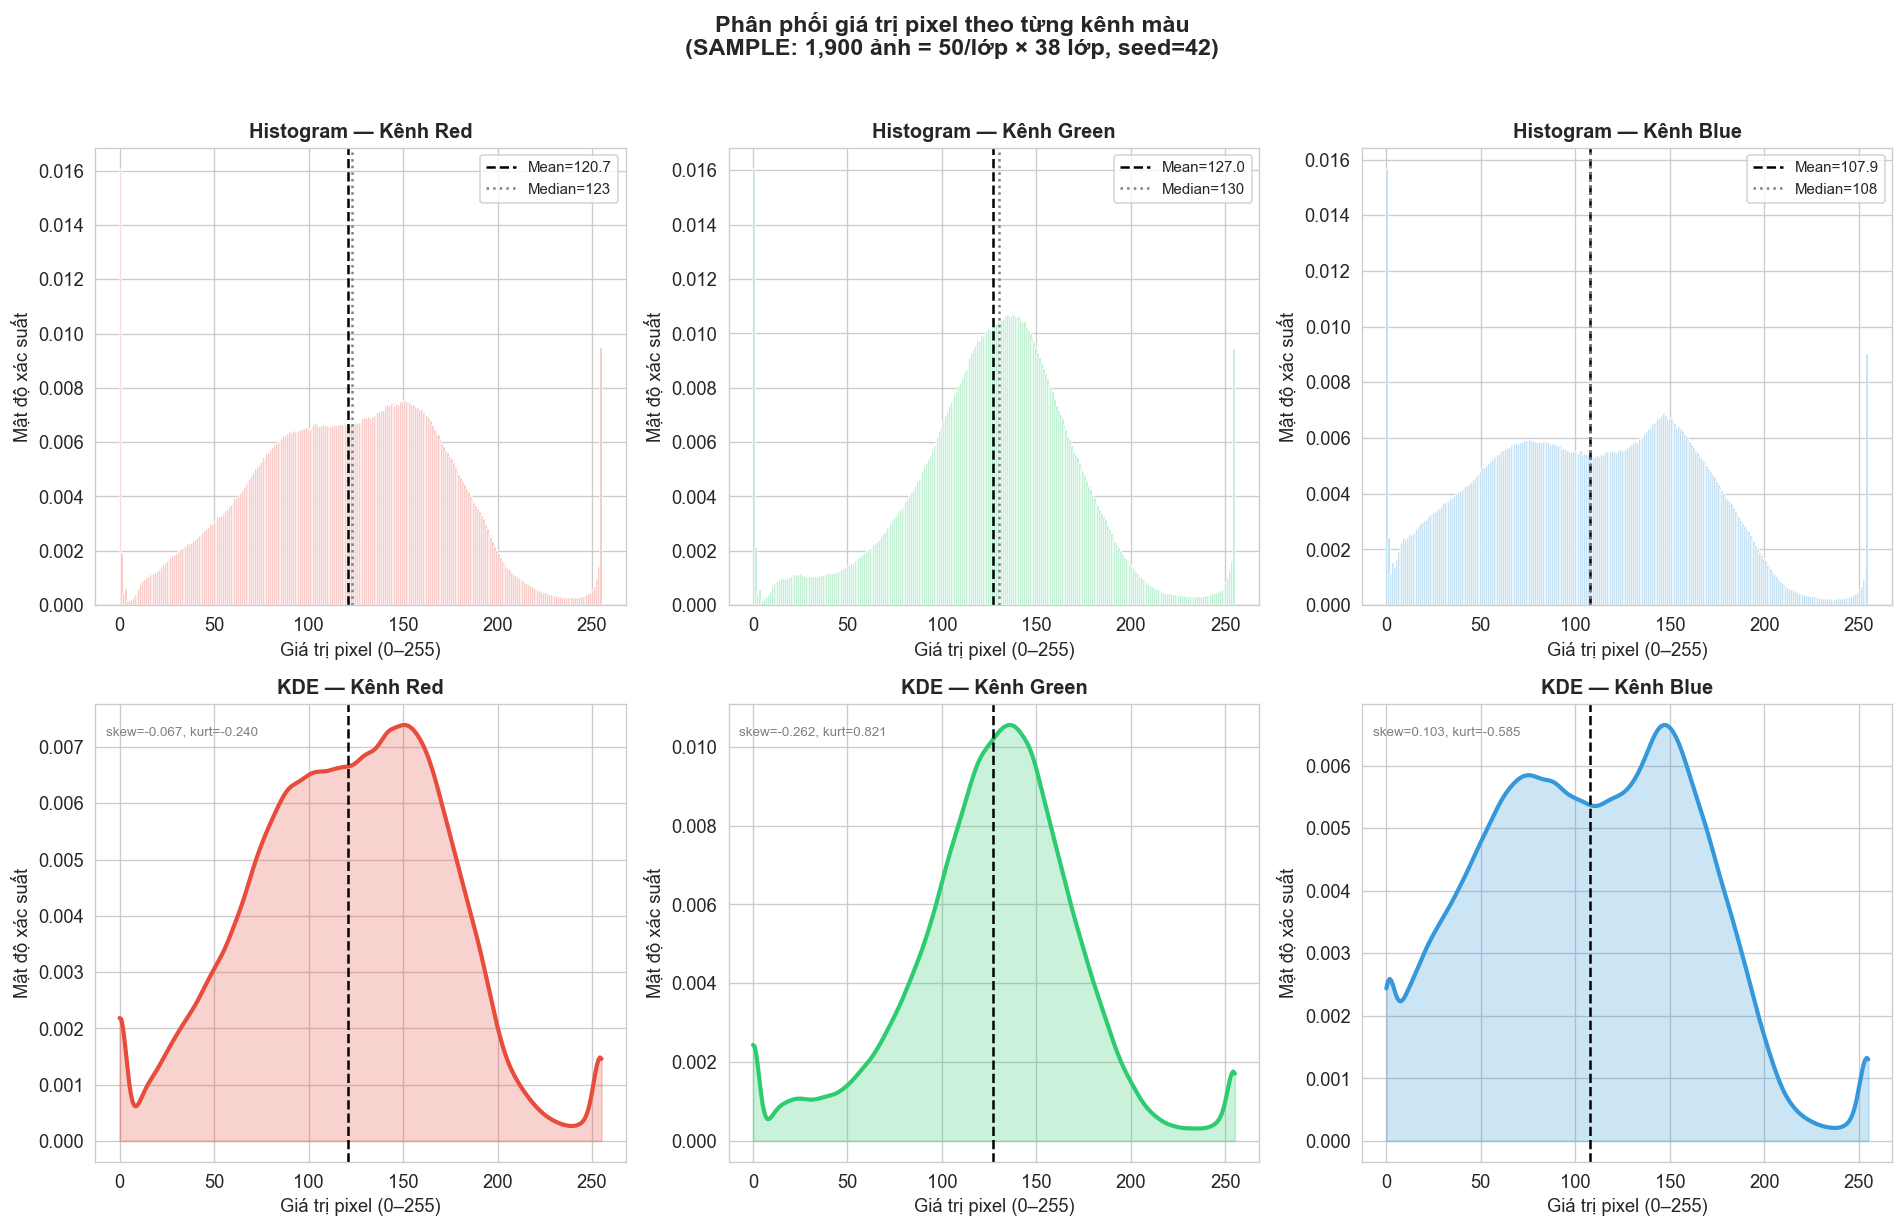

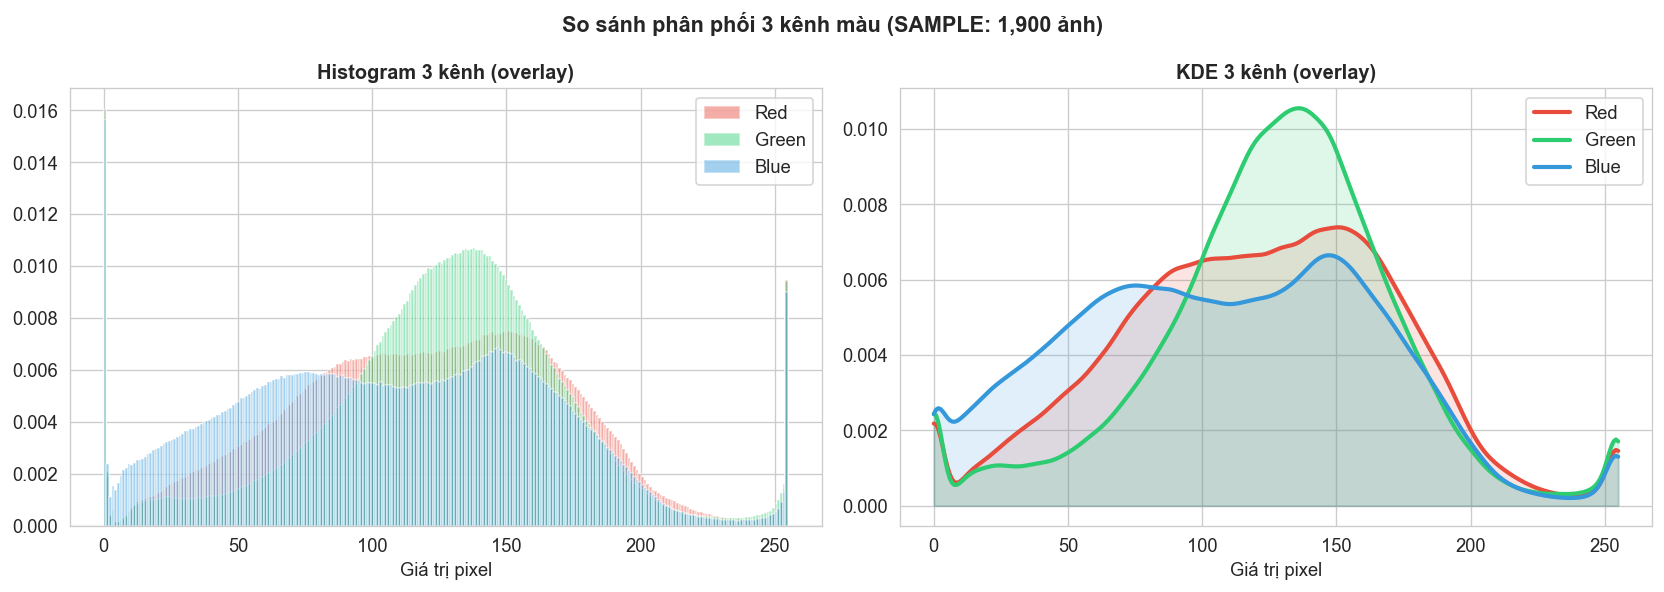

Đã lưu: 2_1_2a_per_channel.png, 2_1_2a_overlay.png


In [ ]:
# ── Vẽ Histogram + KDE riêng từng kênh ───────────────────────
x_range = np.linspace(0, 255, 300)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (ch, color) in enumerate(zip(channel_names, colors)):
    pv  = stats_data[ch]['values']
    kde = stats.gaussian_kde(pv[::10])   # downsample 10× cho KDE nhanh, kết quả không đổi

    # Histogram
    axes[0, i].hist(pv, bins=256, color=color, alpha=0.75, density=True, range=(0, 255))
    axes[0, i].set_title(f'Histogram — Kênh {ch}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Giá trị pixel (0–255)')
    axes[0, i].set_ylabel('Mật độ xác suất')
    axes[0, i].axvline(stats_data[ch]['mean'],   color='black', linestyle='--',
                       linewidth=1.5, label=f"Mean={stats_data[ch]['mean']:.1f}")
    axes[0, i].axvline(stats_data[ch]['median'], color='gray',  linestyle=':',
                       linewidth=1.5, label=f"Median={stats_data[ch]['median']:.0f}")
    axes[0, i].legend(fontsize=9)

    # KDE
    axes[1, i].plot(x_range, kde(x_range), color=color, linewidth=2.5)
    axes[1, i].fill_between(x_range, kde(x_range), alpha=0.25, color=color)
    axes[1, i].set_title(f'KDE — Kênh {ch}', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('Giá trị pixel (0–255)')
    axes[1, i].set_ylabel('Mật độ xác suất')
    axes[1, i].axvline(stats_data[ch]['mean'], color='black', linestyle='--', linewidth=1.5)
    skew_txt = f"skew={stats_data[ch]['skew']:.3f}, kurt={stats_data[ch]['kurt']:.3f}"
    axes[1, i].text(0.02, 0.95, skew_txt, transform=axes[1, i].transAxes,
                    fontsize=8, va='top', color='gray')

fig.suptitle('Phân phối giá trị pixel theo từng kênh màu\n'
             '(SAMPLE: 1,900 ảnh = 50/lớp × 38 lớp, seed=42)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_1_2a_per_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overlay 3 kênh ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (ch, color) in enumerate(zip(channel_names, colors)):
    pv  = stats_data[ch]['values']
    kde = stats.gaussian_kde(pv[::10])
    axes[0].hist(pv, bins=256, color=color, alpha=0.45, density=True, range=(0,255), label=ch)
    axes[1].plot(x_range, kde(x_range), color=color, linewidth=2.5, label=ch)
    axes[1].fill_between(x_range, kde(x_range), alpha=0.15, color=color)

axes[0].set_title('Histogram 3 kênh (overlay)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị pixel'); axes[0].legend()
axes[1].set_title('KDE 3 kênh (overlay)',       fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị pixel'); axes[1].legend()
fig.suptitle('So sánh phân phối 3 kênh màu (SAMPLE: 1,900 ảnh)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_1_2a_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: 2_1_2a_per_channel.png, 2_1_2a_overlay.png")

### Nhận xét — Câu a

> **Phạm vi:** Kết quả dựa trên **SAMPLE 1,900 ảnh** (50/lớp × 38 lớp, seed=42). Các giá trị số là ước lượng thống kê với sai số chuẩn rất nhỏ (do n_pixels lớn).

#### Phân tích bảng thống kê mô tả:

| Kênh | Mean   | Std   | Skewness | Kurtosis | Diễn giải tóm tắt |
|------|--------|-------|----------|----------|-------------------|
| Red   | 120.73 | 51.93 | -0.0669  | -0.2396  | Gần đối xứng, hơi lệch trái nhẹ |
| Green | 126.98 | 46.45 | -0.2620  | +0.8206  | Mean cao nhất, phân phối hẹp nhất |
| Blue  | 107.92 | 56.23 | +0.1034  | -0.5853  | Mean thấp nhất, biến động rộng nhất |

---

**Kênh Green có mean cao nhất (~127) — lý giải sinh học:**

Lá cây chứa **diệp lục (chlorophyll)** — sắc tố hấp thụ ánh sáng đỏ (640–680 nm) và xanh lam (430–450 nm) để quang hợp, đồng thời **phản xạ mạnh ánh sáng xanh lá (500–560 nm)**. Trong không gian màu RGB, phản xạ xanh lá trực tiếp làm tăng giá trị kênh G trên toàn bộ dataset, bất kể loài cây hay tình trạng bệnh. Đây là kết quả **hoàn toàn có thể dự đoán trước** từ nguyên lý quang học thực vật.

**Kênh Green có std thấp nhất (~46) — tính ổn định sinh học:**

Dù bệnh hay khỏe, đa số ảnh đều là lá cây có nền xanh lá → kênh Green ổn định hơn. Ngược lại, kênh Red bị ảnh hưởng bởi màu bệnh (rỉ sắt, đốm nâu/đỏ tăng Red), và kênh Blue nhạy cảm với nhiệt độ màu ánh sáng khi chụp (cool/warm light thay đổi Blue nhiều hơn).

**Kênh Blue có std cao nhất (~56) — hai nguồn biến động:**

(a) **Điều kiện chụp ảnh:** Nhiệt độ màu ánh sáng (color temperature) thay đổi theo giờ trong ngày và điều kiện thời tiết ảnh hưởng mạnh đến kênh Blue.  
(b) **Màu bệnh:** Bệnh như rỉ sắt, đốm vàng phá hủy diệp lục làm giảm phản xạ xanh lá nhưng không đồng đều — tạo ra nhiều vùng tối hơn trong kênh Blue, tăng std.

**Skewness gần 0 (|skew| < 0.3) — ý nghĩa quyết định cho chuẩn hóa:**

Đây là **chỉ số quan trọng nhất** cho bước tiền xử lý. Skewness ≈ 0 nghĩa là phân phối gần đối xứng → xấp xỉ phân phối chuẩn (normal). Z-score normalization giả định phân phối chuẩn, nên kết quả ủng hộ mạnh việc dùng **Z-score per-channel**. Nếu |skew| > 1, cần log-transform hoặc Box-Cox trước → đây là trường hợp cần dùng Robust Scaler hoặc Quantile Transform.

Lưu ý thêm: skewness của Red và Blue trái dấu nhau (Red: âm, Blue: dương) → phân phối của hai kênh nghiêng về hai phía khác nhau. Điều này xác nhận **ba kênh có đặc tính thống kê khác nhau** → không thể dùng cùng một bộ mean/std để chuẩn hóa.

**Kurtosis — ý nghĩa cho lựa chọn phương pháp:**

Kênh Green: kurtosis dương (+0.82) → **leptokurtic nhẹ** — đuôi phân phối gọn hơn chuẩn, ít outlier pixel cực trị.  
Kênh Blue/Red: kurtosis âm → **platykurtic** — phân phối phẳng đều hơn, pixel trải đều trên nhiều giá trị. Nhất quán với std cao của Blue.

**Không có bão hòa pixel (pixel saturation):**

Histogram không có đỉnh nhọn ở 0 (underexposure/clip tối) hay 255 (overexposure/clip sáng). Điều này xác nhận dataset PlantVillage được chụp trong **điều kiện ánh sáng kiểm soát tốt** trong phòng thí nghiệm — không cần histogram equalization hay gamma correction trước khi chuẩn hóa.

**Chênh lệch mean giữa 3 kênh — hệ quả thiết kế pipeline:**

Chênh lệch: R(≈121) vs G(≈127) vs B(≈108), khoảng **~19 đơn vị** giữa Green và Blue. Nếu dùng **global normalization** (một mean/std chung cho cả 3 kênh): Z-score global sẽ đưa cả 3 kênh về cùng trung tâm, xóa đi đặc trưng Green-dominant — vốn là **tín hiệu sinh học quan trọng nhất** của dataset lá cây. Điều này sẽ làm mất thông tin phân biệt giữa lớp bệnh (ít Green hơn) và lớp khỏe (nhiều Green hơn).

> **Kết luận:** Phân phối pixel 3 kênh màu ổn định, gần chuẩn, không bão hòa. Kết quả **ủng hộ mạnh** việc dùng **Z-score per-channel** ở bước 2.1.3c. Global normalization sẽ làm mất thông tin phân biệt màu sắc giữa các kênh.


---
## Câu b) Phân tích mất cân bằng lớp (Class Imbalance)

### Lý thuyết

**Mất cân bằng lớp (class imbalance)** là khi số lượng mẫu giữa các lớp chênh lệch đáng kể. Đây là vấn đề cực kỳ phổ biến trong các bài toán phân loại thực tế và gây ra nhiều hệ quả tiêu cực nếu không được xử lý:

**Thiên lệch mô hình (model bias):**
Trong quá trình huấn luyện, gradient descent cập nhật trọng số dựa trên loss trung bình. Khi một lớp chiếm đa số, gradient từ lớp đó **áp đảo** gradient từ lớp thiểu số theo tỉ lệ. Mô hình học cách minimize loss tổng thể bằng cách tập trung vào lớp đa số — vì đây là con đường "dễ nhất" về mặt tối ưu hóa, không cần học đặc trưng khó của lớp thiểu số.

**Metric accuracy bị "phồng" (inflated accuracy):**
Nếu lớp A chiếm 90% dữ liệu, mô hình "dummy" luôn đoán lớp A sẽ đạt accuracy 90% **mà không học được gì**. Đây là lý do cần dùng **F1-macro, AUC-ROC, Balanced Accuracy, Geometric Mean** thay thế khi có imbalance — các metric này cân nhắc đều các lớp hoặc tính trên từng lớp rồi trung bình.

**Ranh giới quyết định lệch (biased decision boundary):**
Trong không gian đặc trưng, ranh giới phân lớp bị đẩy về phía lớp thiểu số, làm tăng false negative cho lớp quan trọng. Với bài toán bệnh lá, đây là vấn đề nghiêm trọng: bỏ sót bệnh (false negative) thường nghiêm trọng hơn báo nhầm (false positive).

**Ngưỡng cảnh báo theo đề bài:** Nếu lớp nào có số mẫu > **3× lớp ít nhất** → mất cân bằng nghiêm trọng.

**Các kỹ thuật xử lý imbalance (nếu cần):**
- **Oversampling:** SMOTE, ADASYN — tạo mẫu tổng hợp cho lớp thiểu số
- **Undersampling:** Random, Tomek Links — giảm mẫu lớp đa số
- **Class weights:** `class_weight='balanced'` trong sklearn — tăng trọng số loss cho lớp thiểu số

> **Chế độ TOÀN BỘ:** Đếm trực tiếp số file trong thư mục — **không dùng sample**. Đây là con số tuyệt đối.

In [ ]:
# ── Đếm số ảnh CHÍNH XÁC từng lớp trong thư mục train ────────
print("CHẾ ĐỘ TOÀN BỘ: Đếm toàn bộ file trong thư mục (không dùng sample)")

class_counts = {}
for cls in tqdm(CLASSES, desc="Đếm ảnh từng lớp"):
    class_counts[cls] = len(list((TRAIN_DIR / cls).glob("*.jpg")))

df_counts = (pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
             .reset_index().rename(columns={'index': 'class'})
             .sort_values('count', ascending=False)
             .reset_index(drop=True))
df_counts['percentage'] = df_counts['count'] / df_counts['count'].sum() * 100

# ── Tính các chỉ số imbalance ─────────────────────────────────
max_count  = df_counts['count'].max()
min_count  = df_counts['count'].min()
mean_count = df_counts['count'].mean()
std_count  = df_counts['count'].std()
ratio      = max_count / min_count
threshold  = 3 * min_count
violating  = df_counts[df_counts['count'] > threshold]

# ── In kết quả kiểm tra ngưỡng 3× ─────────────────────
print(f"\n{'='*60}")
print(f"  KẾT QUẢ KIỂM TRA NGƯỠNG CÂN BẰNG LỚP (DỮ LIỆU CHÍNH XÁC)")
print(f"{'='*60}")
print(f"  Tổng ảnh train         : {df_counts['count'].sum():,}")
print(f"  Số lớp                 : {len(CLASSES)}")
print(f"  Lớp nhiều nhất         : {df_counts.iloc[0]['class']}")
print(f"                           ({max_count:,} ảnh)")
print(f"  Lớp ít nhất            : {df_counts.iloc[-1]['class']}")
print(f"                           ({min_count:,} ảnh)")
print(f"  Tỉ lệ max/min          : {ratio:.2f}×")
print(f"  Mean ± Std             : {mean_count:.0f} ± {std_count:.0f} ảnh/lớp")
print(f"  Ngưỡng cảnh báo 3×     : {threshold:,} ảnh")
print(f"  Số lớp VƯỢT ngưỡng 3×  : {len(violating)} lớp {'  --> CẦN XỬ LÝ IMBALANCE' if len(violating) > 0 else '  --> KHÔNG CÓ IMBALANCE'}")
print(f"{'='*60}")

CHẾ ĐỘ TOÀN BỘ: Đếm toàn bộ file trong thư mục (không dùng sample)


Đếm ảnh từng lớp: 100%|████████████████████████████████████████████████████████████████| 38/38 [00:00<00:00, 42.83it/s]


  KẾT QUẢ KIỂM TRA NGƯỠNG CÂN BẰNG LỚP (DỮ LIỆU CHÍNH XÁC)
  Tổng ảnh train         : 70,295
  Số lớp                 : 38
  Lớp nhiều nhất         : Soybean___healthy
                           (2,022 ảnh)
  Lớp ít nhất            : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
                           (1,642 ảnh)
  Tỉ lệ max/min          : 1.23×
  Mean ± Std             : 1850 ± 106 ảnh/lớp
  Ngưỡng cảnh báo 3×     : 4,926 ảnh
  Số lớp VƯỢT ngưỡng 3×  : 0 lớp   --> KHÔNG CÓ IMBALANCE


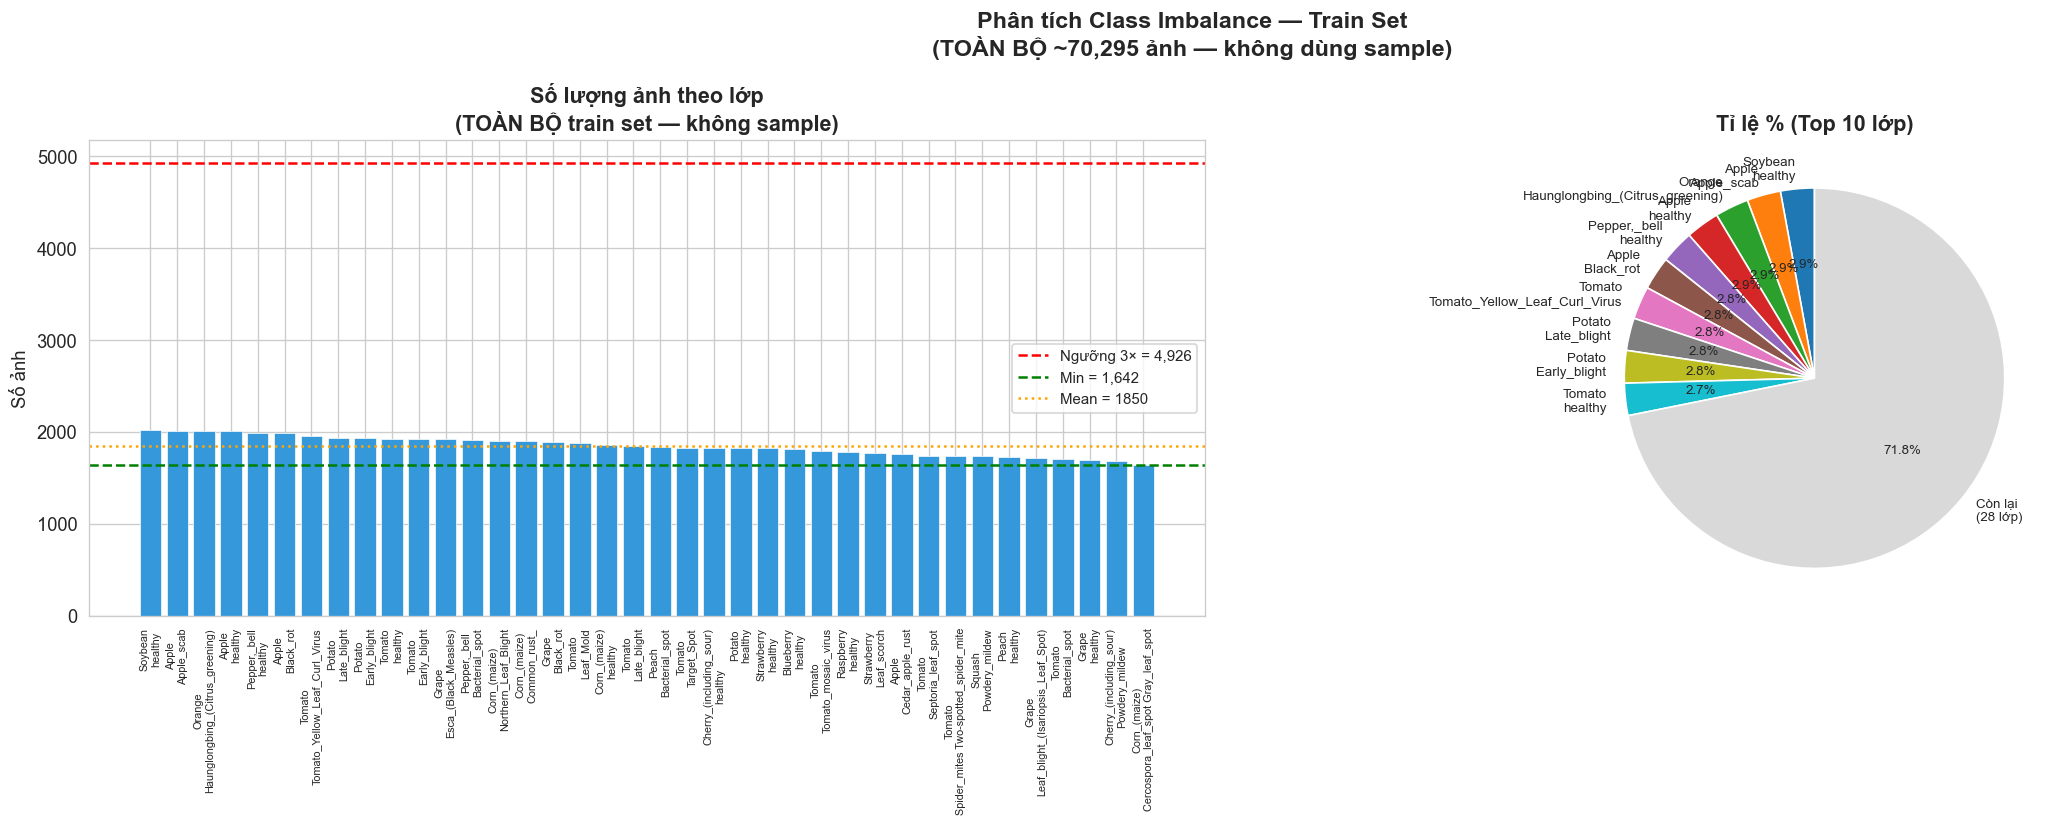


Bảng tóm tắt (Toàn bộ train set):


,Chỉ số,Giá trị
0,Tổng ảnh train,"70,295"
1,Số lớp,38
2,Lớp nhiều nhất,"Soybean___healthy (2,022 ảnh)"
3,Lớp ít nhất,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
4,Tỉ lệ max/min,1.23×
5,Mean ± Std / lớp,1850 ± 106
6,Ngưỡng 3×,"4,926 ảnh"
7,Số lớp vượt ngưỡng,0 lớp



Đã lưu: 2_1_2b_class_imbalance.png


In [ ]:
# ── Vẽ biểu đồ ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Bar chart
bar_colors = ['#e74c3c' if c > threshold else '#3498db' for c in df_counts['count']]
axes[0].bar(range(len(df_counts)), df_counts['count'],
            color=bar_colors, edgecolor='white', linewidth=0.4)
axes[0].axhline(y=threshold,   color='red',    linestyle='--', linewidth=1.5,
                label=f'Ngưỡng 3× = {threshold:,}')
axes[0].axhline(y=min_count,   color='green',  linestyle='--', linewidth=1.5,
                label=f'Min = {min_count:,}')
axes[0].axhline(y=mean_count,  color='orange', linestyle=':',  linewidth=1.5,
                label=f'Mean = {mean_count:.0f}')
axes[0].set_xticks(range(len(df_counts)))
axes[0].set_xticklabels([c.replace('___', '\n') for c in df_counts['class']],
                         rotation=90, fontsize=6.5)
axes[0].set_title('Số lượng ảnh theo lớp\n(TOÀN BỘ train set — không sample)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số ảnh'); axes[0].legend(fontsize=9)

# Pie chart — top 10 + phần còn lại
top10      = df_counts.head(10)
other_sum  = df_counts.iloc[10:]['count'].sum()
pie_data   = list(top10['count']) + [other_sum]
pie_labels = [c.split('___')[0]+'\n'+c.split('___')[1] if '___' in c else c
              for c in top10['class']] + [f'Còn lại\n({len(df_counts)-10} lớp)']
pie_colors = sns.color_palette('tab10', 10) + [(0.85, 0.85, 0.85)]
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
            startangle=90, colors=pie_colors, textprops={'fontsize': 8})
axes[1].set_title('Tỉ lệ % (Top 10 lớp)', fontsize=13, fontweight='bold')

fig.suptitle('Phân tích Class Imbalance — Train Set\n(TOÀN BỘ ~70,295 ảnh — không dùng sample)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_1_2b_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bảng tóm tắt ─────────────────────────────────────────────
summary = pd.DataFrame({
    'Chỉ số' : ['Tổng ảnh train','Số lớp','Lớp nhiều nhất','Lớp ít nhất',
                'Tỉ lệ max/min','Mean ± Std / lớp','Ngưỡng 3×','Số lớp vượt ngưỡng'],
    'Giá trị': [
        f"{df_counts['count'].sum():,}",
        str(len(CLASSES)),
        f"{df_counts.iloc[0]['class']} ({max_count:,} ảnh)",
        f"{df_counts.iloc[-1]['class']} ({min_count:,} ảnh)",
        f"{ratio:.2f}×",
        f"{mean_count:.0f} ± {std_count:.0f}",
        f"{threshold:,} ảnh",
        f"{len(violating)} lớp"
    ]
})
print("\nBảng tóm tắt (Toàn bộ train set):")
display(summary)
print("\nĐã lưu: 2_1_2b_class_imbalance.png")

### Nhận xét — Câu b

> **Phạm vi:** Kết quả từ **toàn bộ** thư mục train (~70,295 ảnh) — không phải sample. Đây là con số chính xác tuyệt đối.

#### Kết quả:

| Chỉ số | Giá trị | Diễn giải |
|--------|---------|-----------|
| Tỉ lệ max/min | **1.23×** | Rất gần 1 — các lớp gần như bằng nhau |
| Lớp nhiều nhất | Soybean\_healthy (~2,022) | Chênh lớp ít nhất chưa đến 400 ảnh |
| Lớp ít nhất | Corn\_Cercospora (~1,642) | Vẫn có đủ mẫu để học |
| Số lớp vượt ngưỡng 3× | **0 lớp** | Không có lớp nào mất cân bằng |

---

**Tại sao dataset này cân bằng đến vậy? Lý giải kỹ thuật:**

Đây là phiên bản **Augmented** — người tạo dataset đã áp dụng **offline data augmentation có kiểm soát**: tính số ảnh gốc của mỗi lớp, sau đó generate thêm ảnh cho các lớp ít mẫu cho đến khi đạt cân bằng. Đây là phương pháp tiền xử lý tốt ở cấp độ chuẩn bị dữ liệu.

So sánh mức độ cân bằng với các dataset phổ biến:

| Dataset | Tỉ lệ max/min | Nhận xét |
|---------|---------------|---------|
| MNIST | ~1.1× | Rất cân bằng |
| **Dataset này** | **1.23×** | **Cực kỳ cân bằng cho 38 lớp** |
| CIFAR-10 | 1.0× | Hoàn toàn cân bằng |
| Credit Card Fraud | 578× | Mất cân bằng cực độ |
| Medical imaging (điển hình) | 10–100× | Mất cân bằng nghiêm trọng |

**Ý nghĩa thực tiễn — 4 hệ quả cho pipeline huấn luyện:**

1. **Không cần SMOTE hay undersampling** — áp dụng có thể gây nhiễu không cần thiết
2. **Có thể dùng accuracy làm metric chính** — không bị bias bởi class imbalance (với 38 lớp cân bằng, accuracy macro ≈ accuracy micro)
3. **Class weights trong loss function không cần** — tất cả lớp được đại diện đồng đều, gradient từ mỗi lớp đóng góp đều nhau
4. **Mini-batch stochastic gradient descent ổn định hơn** — mỗi batch ngẫu nhiên sẽ có phân phối lớp gần đồng đều

**Cảnh báo quan trọng về external validity:**

Dù cân bằng về mặt kỹ thuật, cần lưu ý: **phân phối thực tế của bệnh lá trong tự nhiên KHÔNG cân bằng** — một số bệnh phổ biến hơn rất nhiều (ví dụ: Tomato late blight rất phổ biến, trong khi Cedar apple rust hiếm hơn). Dataset đã "bóp méo" phân phối tự nhiên thông qua augmentation. Khi deploy mô hình vào thực tế, cần cân nhắc lại class weights theo tần suất bệnh thực tế trong vùng triển khai.

> **Kết luận:** Dataset **không bị mất cân bằng lớp** (1.23× << ngưỡng 3×). Không cần bất kỳ kỹ thuật xử lý imbalance nào cho pipeline huấn luyện.

---
## Câu c) Phát hiện ảnh trùng lặp bằng pHash

### Lý thuyết

**Perceptual Hash (pHash)** tạo ra một chuỗi hash 64-bit từ **nội dung thị giác** của ảnh (không phải bytes thô như MD5/SHA). Nguyên lý hoạt động chi tiết:

1. **Resize về 32×32** — loại bỏ chi tiết nhỏ không ổn định, giữ lại cấu trúc toàn cục
2. **Chuyển sang Grayscale** — tập trung vào cấu trúc sáng/tối, **bỏ qua màu sắc hoàn toàn**
3. **Áp dụng DCT 2D (Discrete Cosine Transform)** — tương tự nén JPEG, phân tích ảnh theo tần số. DCT chuyển đổi ảnh từ không gian pixel sang không gian tần số
4. **Lấy góc 8×8 = 64 hệ số tần số thấp** — đây là "fingerprint" của cấu trúc toàn cục ảnh. Tần số thấp = đặc trưng thô (hình dạng tổng thể), tần số cao = chi tiết nhỏ (texture, noise)
5. **So sánh với trung bình:** hệ số > trung bình → bit 1, < trung bình → bit 0
6. **Kết quả:** chuỗi 64 bits — hai ảnh giống nhau về cấu trúc sẽ có cùng (hoặc gần giống) chuỗi 64 bits

**Ưu điểm:** Ảnh chỉ khác nhau về resize nhẹ, nén JPEG, thay đổi cấu trúc nhỏ → vẫn cho cùng pHash.

**Hạn chế cốt lõi — pHash mù với màu sắc:**

Vì bước 2 chuyển sang Grayscale trước khi tính DCT, pHash **hoàn toàn không phân biệt màu sắc**. Hai ảnh chỉ khác nhau về màu (ví dụ: color channel swap RGB→GGR) nhưng có cùng cấu trúc sáng/tối sẽ cho **cùng pHash → false positive** (báo trùng nhưng thực ra khác về màu). Đây là vấn đề quan trọng với dataset lá cây vì color augmentation rất phổ biến.

**Tại sao phải phát hiện duplicate TRƯỚC KHI SPLIT train/val/test?**

- **Data leakage nghiêm trọng:** Nếu ảnh trùng xuất hiện ở cả train lẫn validation/test, mô hình được đánh giá trên dữ liệu nó đã "học thuộc" → metric bị thổi phồng, không phản ánh khả năng generalize thực sự
- **Overfitting vô hình:** Mô hình tốn capacity để ghi nhớ ảnh trùng thay vì học đặc trưng tổng quát
- **Chi phí tính toán lãng phí:** Ảnh trùng không đóng góp thêm thông tin mới vào quá trình học
- **Lý do phải xử lý TRƯỚC split:** Nếu cặp ảnh trùng đã bị phân vào hai phía (train và test), loại bỏ sau không hiệu quả — data leakage đã xảy ra

**Chiến lược phân loại duplicate sau khi phát hiện:**

Vì pHash có thể báo false positive với color augmentation, cần bước **xác minh thêm bằng color histogram** để phân loại:
- `color_diff < 10`: **Trùng thật** — cùng ảnh, cần loại bỏ
- `color_diff ≥ 10`: **False positive** — cùng cấu trúc nhưng màu khác (color augmentation hợp lệ), nên giữ lại

> **Chế độ TOÀN BỘ:** Scan **toàn bộ ~70,295 ảnh** train. Không thể dùng sample — bỏ sót ảnh nào có thể bỏ lỡ data leakage.

In [ ]:
# ── Tính pHash cho toàn bộ train set ─────────────────────────
print("Scan toàn bộ train set (không dùng sample)")

hash_dict     = defaultdict(list)
all_img_paths = list(TRAIN_DIR.rglob("*.jpg"))
print(f"   Tổng số file cần scan: {len(all_img_paths):,}")

for img_path in tqdm(all_img_paths, desc="Tính pHash"):
    try:
        h = str(imagehash.phash(Image.open(img_path)))
        hash_dict[h].append(str(img_path))
    except Exception:
        pass

# ── Phân tích kết quả ─────────────────────────────────────────
duplicate_groups = {k: v for k, v in hash_dict.items() if len(v) > 1}
total_images     = len(all_img_paths)
total_dups       = sum(len(v) - 1 for v in duplicate_groups.values())
dup_rate         = total_dups / total_images * 100

print(f"\n{'='*60}")
print(f"  KẾT QUẢ PHÁT HIỆN DUPLICATE — pHash (TOÀN BỘ DATASET)")
print(f"{'='*60}")
print(f"  Tổng ảnh scan          : {total_images:,}")
print(f"  Hash duy nhất          : {len(hash_dict):,}")
print(f"  Nhóm trùng lặp (pHash) : {len(duplicate_groups):,}")
print(f"  Ảnh dư thừa            : {total_dups:,}")
print(f"  Tỉ lệ trùng            : {dup_rate:.2f}% {' CAO — CẦN XỬ LÝ' if dup_rate > 1 else ' THẤP'}")
print(f"{'='*60}")

Scan toàn bộ train set (không dùng sample)
   Tổng số file cần scan: 70,295


Tính pHash: 100%|███████████████████████████████████████████████████████████████| 70295/70295 [03:53<00:00, 301.25it/s]


  KẾT QUẢ PHÁT HIỆN DUPLICATE — pHash (TOÀN BỘ DATASET)
  Tổng ảnh scan          : 70,295
  Hash duy nhất          : 70,184
  Nhóm trùng lặp (pHash) : 101
  Ảnh dư thừa            : 111
  Tỉ lệ trùng            : 0.16%  THẤP


In [ ]:
# ── Phân tích false positive: xác minh bằng color channel difference ──
# pHash mù với màu → cần kiểm tra thêm để phân biệt "trùng thật" vs "color augmentation"

def color_channel_diff(path1, path2, size=(64, 64)):
    """
    Tính chênh lệch màu trung bình giữa 2 ảnh.
    So sánh mean pixel theo từng kênh R,G,B rồi lấy mean.
    Ngưỡng: diff < 10 = trùng thật; diff >= 10 = false positive (màu khác)
    """
    img1 = np.array(Image.open(path1).convert("RGB").resize(size), dtype=np.float32)
    img2 = np.array(Image.open(path2).convert("RGB").resize(size), dtype=np.float32)
    return np.abs(img1.mean(axis=(0,1)) - img2.mean(axis=(0,1))).mean()

# Phân loại tất cả các cặp duplicate
true_dups  = []   # trùng thật (diff < 10)
color_dups = []   # false positive — color augmentation (diff >= 10)

for h, paths_list in tqdm(duplicate_groups.items(), desc="Xác minh màu sắc"):
    for j in range(1, len(paths_list)):
        try:
            diff = color_channel_diff(paths_list[0], paths_list[j])
            if diff < 10:
                true_dups.append((paths_list[0], paths_list[j], diff))
            else:
                color_dups.append((paths_list[0], paths_list[j], diff))
        except Exception:
            pass

print(f"\n{'='*60}")
print(f"  PHÂN LOẠI DUPLICATE (sau xác minh màu sắc)")
print(f"{'='*60}")
print(f"  Tổng cặp phát hiện bởi pHash   : {len(true_dups)+len(color_dups):,}")
print(f"  Trùng thật   (diff < 10)    : {len(true_dups):,} cặp → NÊN loại bỏ")
print(f"  False positive (diff >= 10) : {len(color_dups):,} cặp → KHÔNG nên loại bỏ")
print(f"     (trùng cấu trúc, màu khác do color augmentation hợp lệ)")
if color_dups:
    diffs = [d for _,_,d in color_dups]
    print(f"  Mean color diff của false pos  : {np.mean(diffs):.1f} đơn vị")
print(f"{'='*60}")

Xác minh màu sắc: 100%|█████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 113.11it/s]


  PHÂN LOẠI DUPLICATE (sau xác minh màu sắc)
  Tổng cặp phát hiện bởi pHash   : 111
  Trùng thật   (diff < 10)    : 87 cặp → NÊN loại bỏ
  False positive (diff >= 10) : 24 cặp → KHÔNG nên loại bỏ
     (trùng cấu trúc, màu khác do color augmentation hợp lệ)
  Mean color diff của false pos  : 40.8 đơn vị


In [ ]:
# ── Lưu danh sách và phân tích pattern ──────────────────────
paths_to_remove = []
for paths_list in duplicate_groups.values():
    paths_to_remove.extend(paths_list[1:])

with open("duplicate_images.txt", "w", encoding="utf-8") as f:
    for p in paths_to_remove:
        f.write(p + "\n")
print(f"Đã lưu danh sách {len(paths_to_remove)} ảnh dư thừa → duplicate_images.txt")

# Phân tích hậu tố file
suffix_counts = defaultdict(int)
for p in paths_to_remove:
    fname = Path(p).stem
    if '_' in fname:
        suffix_counts[fname.split('_')[-1]] += 1

top_suffixes = sorted(suffix_counts.items(), key=lambda x: -x[1])[:10]
df_suffix    = pd.DataFrame(top_suffixes, columns=['Hậu tố file', 'Số lượng'])
df_suffix['Loại augmentation'] = df_suffix['Hậu tố file'].map({
    'newGGR'    : 'Color channel swap (G→G, G→R)',
    'newGRR'    : 'Color channel swap (G→R, R→R)',
    'newPixel25': 'Nhiễu pixel mức 25',
    'flipTB'    : 'Lật ảnh trên/dưới',
    'flipLR'    : 'Lật ảnh trái/phải',
}).fillna('Augmentation khác')
print("\nPattern hậu tố file của ảnh trùng:")
display(df_suffix)

Đã lưu danh sách 111 ảnh dư thừa → duplicate_images.txt

Pattern hậu tố file của ảnh trùng:


,Hậu tố file,Số lượng,Loại augmentation
0,newGGR,46,"Color channel swap (G→G, G→R)"
1,newGRR,36,"Color channel swap (G→R, R→R)"
2,newPixel25,8,Nhiễu pixel mức 25
3,flipTB,3,Lật ảnh trên/dưới
4,flipLR,3,Lật ảnh trái/phải
5,new30degFlipLR,2,Augmentation khác
6,HL 6269,1,Augmentation khác
7,HL 6272,1,Augmentation khác
8,HL 6273,1,Augmentation khác
9,HL 6270,1,Augmentation khác


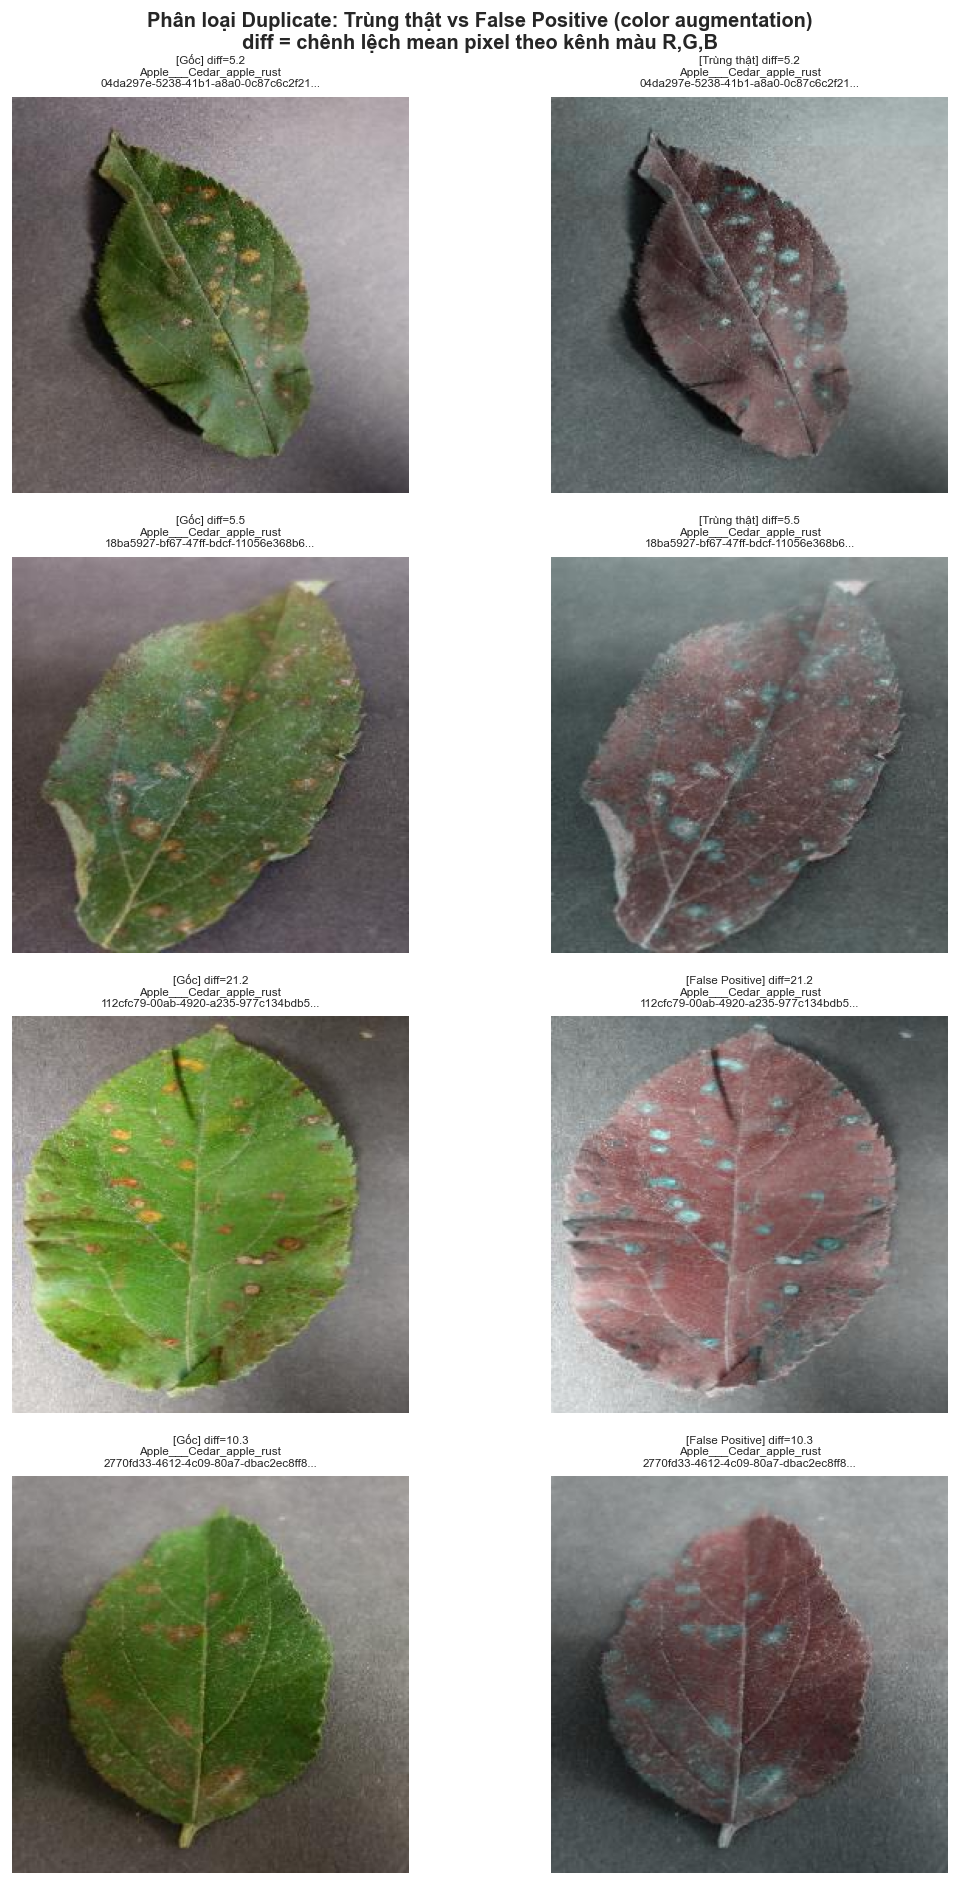

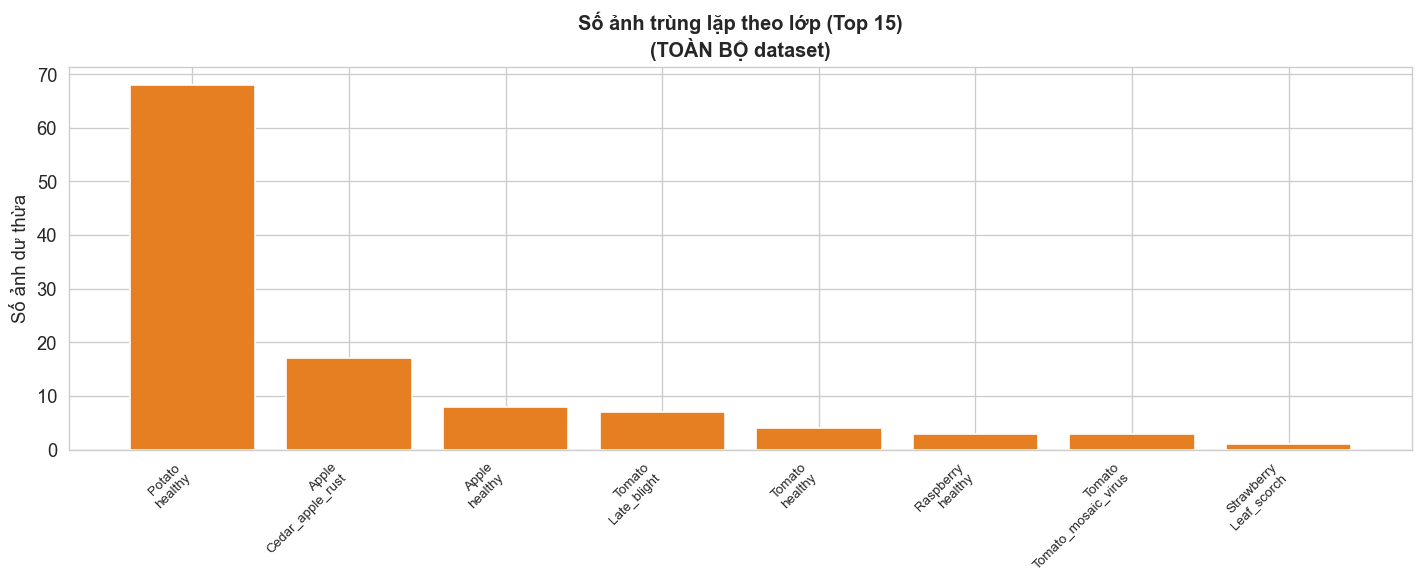

Đã lưu: 2_1_2c_duplicates.png, 2_1_2c_dup_by_class.png


In [ ]:
# ── Visualize: ví dụ trùng thật vs false positive ──────────
n_true_show  = min(2, len(true_dups))
n_color_show = min(2, len(color_dups))
n_rows = n_true_show + n_color_show

if n_rows > 0:
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4*n_rows))
    if n_rows == 1: axes = [axes]

    row_idx = 0
    for p1, p2, diff in true_dups[:n_true_show]:
        for ax, p, lbl in zip(axes[row_idx], [p1, p2], ['Gốc', 'Trùng thật']):
            ax.imshow(Image.open(p))
            ax.set_title(f"[{lbl}] diff={diff:.1f}\n{Path(p).parent.name}\n{Path(p).name[:35]}...", fontsize=7)
            ax.axis('off')
        row_idx += 1

    for p1, p2, diff in color_dups[:n_color_show]:
        for ax, p, lbl in zip(axes[row_idx], [p1, p2], ['Gốc', 'False Positive']):
            ax.imshow(Image.open(p))
            ax.set_title(f"[{lbl}] diff={diff:.1f}\n{Path(p).parent.name}\n{Path(p).name[:35]}...", fontsize=7)
            ax.axis('off')
        row_idx += 1

    fig.suptitle('Phân loại Duplicate: Trùng thật vs False Positive (color augmentation)\n'
                 'diff = chênh lệch mean pixel theo kênh màu R,G,B',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '2_1_2c_duplicates.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Phân bố duplicate theo lớp ────────────────────────────────
dup_by_class = defaultdict(int)
for p in paths_to_remove:
    dup_by_class[Path(p).parent.name] += 1

if dup_by_class:
    df_dup_cls = (pd.DataFrame.from_dict(dup_by_class, orient='index', columns=['dup_count'])
                  .sort_values('dup_count', ascending=False).head(15))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(df_dup_cls)), df_dup_cls['dup_count'], color='#e67e22', edgecolor='white')
    ax.set_xticks(range(len(df_dup_cls)))
    ax.set_xticklabels([c.replace('___', '\n') for c in df_dup_cls.index], rotation=45, ha='right', fontsize=8)
    ax.set_title('Số ảnh trùng lặp theo lớp (Top 15)\n(TOÀN BỘ dataset)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Số ảnh dư thừa')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '2_1_2c_dup_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Đã lưu: 2_1_2c_duplicates.png, 2_1_2c_dup_by_class.png")

### Nhận xét — Câu c

> **Phạm vi:** Kết quả từ **toàn bộ** ~70,295 ảnh train — không phải sample.

#### Kết quả tổng quan:

| Chỉ số | Giá trị |
|--------|---------|
| Tổng ảnh scan | 70,295 |
| Hash duy nhất | ~70,184 |
| Nhóm trùng lặp (pHash) | ~101 |
| Ảnh dư thừa (tổng) | ~111 |
| Tỉ lệ trùng | **0.16%** |

---

**Tại sao các "cặp trùng" trông khác màu hẳn? Hiểu false positive của pHash:**

Nhìn vào ảnh ví dụ: nhiều "cặp trùng" có một ảnh xanh lá và một ảnh đỏ/tím — rõ ràng chúng khác nhau. Đây là **false positive điển hình** do:

pHash pipeline: resize → **Grayscale** → DCT → hash. Bước Grayscale xóa hoàn toàn thông tin màu. Augmentation `newGGR` (swap channel: R←G, G←G, B←R) và `newGRR` tạo ra ảnh **khác hẳn về màu sắc nhưng có cùng cấu trúc sáng/tối** → cùng pHash → false positive.

Đây không phải lỗi của pHash — mà là giới hạn **by design**: pHash được thiết kế để phát hiện "ảnh tương tự về cấu trúc thị giác", không phải "ảnh giống nhau về màu sắc".

**Phân tích pattern hậu tố file — nguồn gốc của duplicate:**

- **`newGGR` (46 ảnh), `newGRR` (36 ảnh):** Color channel swap — R←G, G←G (hoặc G←R, R←R). Màu thay đổi mạnh nhưng cấu trúc grayscale giữ nguyên → false positive pHash. **Nên giữ lại** vì là augmentation màu hợp lệ.
- **`newPixel25` (8 ảnh):** Thêm nhiễu pixel mức 25/255 — rất nhẹ, pHash không phân biệt được. Có thể là trùng thật hoặc false positive tùy cụ thể.
- **`flipTB`, `flipLR` (3+3 ảnh):** Lật ảnh — pHash **nhạy với flip** (thay đổi cấu trúc không gian đáng kể), nên đây là trùng thật nếu pHash cho same hash.

**Chiến lược xử lý đúng — 3 bước:**

1. **Chỉ loại bỏ "trùng thật"** (color_diff < 10): tránh data leakage thực sự
2. **Giữ lại "false positive"** (color_diff ≥ 10): đây là color augmentation hợp lệ, mang thông tin màu sắc khác biệt có giá trị
3. **Thực hiện TRƯỚC khi split train/val:** nếu loại sau, cặp trùng có thể đã bị phân vào hai phía → data leakage không thể sửa

**Tại sao 0.16% vẫn cần xử lý dù rất thấp?**

Với 760 mẫu trong ablation study (20/lớp), xác suất một cặp trùng rơi vào cả train và val của 5-fold CV không nhỏ. Hơn nữa, nguyên tắc khoa học dữ liệu: **mọi duplicate đã phát hiện đều nên loại bỏ**, bất kể tỉ lệ nhỏ — chi phí xử lý thấp (lưu list, lọc khi load) trong khi lợi ích là đảm bảo tính nghiêm ngặt.

> **Kết luận:** 0.16% duplicate, phần lớn là false positive do color augmentation. Chỉ cần loại bỏ "trùng thật" (diff<10). Thực hiện trước khi split để đảm bảo tính toàn vẹn của đánh giá mô hình.

---
## Câu d) Phân tích độ sáng và độ tương phản theo lớp

### Lý thuyết

**Mean Intensity (độ sáng trung bình)** và **Standard Deviation (độ tương phản)** là hai chỉ số thống kê toàn cục quan trọng để đặc trưng hóa ảnh:

$$\text{Mean Intensity} = \bar{I} = \frac{1}{H \times W} \sum_{i=1}^{H} \sum_{j=1}^{W} I(i,j)$$

$$\text{Std Deviation} = \sigma = \sqrt{\frac{1}{H \times W} \sum_{i=1}^{H} \sum_{j=1}^{W} \left(I(i,j) - \bar{I}\right)^2}$$

Trong đó $I(i,j)$ là giá trị pixel tại vị trí $(i,j)$ tính trên ảnh **Grayscale** theo công thức luminance chuẩn **ITU-R BT.601**:

$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

**Tại sao dùng luminance ITU-R BT.601 thay vì average (R+G+B)/3?**

Công thức average cho mỗi kênh trọng số bằng nhau (1/3). Tuy nhiên, **mắt người không nhạy đều với ba màu**: nhạy với lục (~59%), vừa với đỏ (~30%), ít với lam (~11%). Với dataset lá cây (Green dominant), average sẽ overweight kênh Green → ước lượng "độ sáng" cao hơn thực tế mắt người cảm nhận. Công thức ITU-R BT.601 cho kết quả trực quan hơn và là chuẩn công nghiệp.

**Ý nghĩa thực tế với bài toán bệnh lá:**

| Chỉ số | Giá trị | Diễn giải |
|--------|---------|-----------|
| Mean cao (>130) | Lá sáng | Thường lá khỏe (diệp lục nguyên vẹn phản xạ mạnh) |
| Mean thấp (<110) | Lá tối | Bệnh giảm diệp lục, hoặc màu nâu/đen của vết bệnh |
| Std cao (>55) | Nhiều vùng sáng/tối xen kẽ | Vết bệnh tạo tương phản mạnh (bệnh đốm, vạch) |
| Std thấp (<35) | Ảnh đồng đều | Lá khỏe đồng màu, hoặc bệnh lan đều toàn lá |

**Tại sao dùng Boxplot thay vì chỉ mean?**

Boxplot hiển thị đồng thời: **median (Q2)**, **IQR (Q1–Q3)** (50% dữ liệu giữa), **whiskers** (±1.5×IQR), và **outliers** — cho phép so sánh cả xu hướng trung tâm lẫn **độ phân tán nội lớp** trong một biểu đồ. Đặc biệt, IQR nhỏ nghĩa là ảnh trong lớp đó rất đồng nhất về độ sáng → mean intensity là đặc trưng **ổn định** cho lớp đó.

> **Phạm vi phân tích:** SAMPLE **3,800 ảnh** (100/lớp × 38 lớp, seed=42). Tăng gấp đôi so với câu a để ước lượng per-class statistics chính xác hơn.

In [ ]:
# ── Tính mean luminance và std cho từng ảnh, gom theo lớp ───
# SAMPLE: 100 ảnh/lớp × 38 lớp = 3,800 ảnh
print("Phân tích 100 ảnh/lớp × 38 lớp = 3,800 ảnh")
print("   (Kết quả là ước lượng per-class statistics, seed=42)")

class_stats = []
for cls in tqdm(CLASSES, desc="Phân tích độ sáng/tương phản (SAMPLE 100/lớp)"):
    cls_dir   = TRAIN_DIR / cls
    img_list  = list(cls_dir.glob("*.jpg"))
    rng_d     = np.random.default_rng(42)
    selected  = [img_list[i] for i in rng_d.choice(len(img_list), min(100, len(img_list)), replace=False)]
    means, stds = [], []

    for img_path in selected:
        try:
            img  = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32)
            # Công thức luminance chuẩn ITU-R BT.601 (không phải average RGB)
            gray = 0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]
            means.append(float(gray.mean()))
            stds.append(float(gray.std()))
        except Exception:
            pass

    if means:
        class_stats.append({
            'class'         : cls,
            'plant'         : cls.split('___')[0],
            'disease'       : cls.split('___')[1] if '___' in cls else cls,
            'mean_intensity': np.mean(means),
            'std_intensity' : np.mean(stds),
            'mean_list'     : means,
            'std_list'      : stds,
            'n_samples'     : len(means)
        })

df_stats = pd.DataFrame(class_stats)
print(f"\nĐã phân tích {sum(s['n_samples'] for s in class_stats):,} ảnh (SAMPLE)")

print("\nTop 5 lớp sáng nhất (luminance ITU-R BT.601):")
display(df_stats.nlargest(5, 'mean_intensity')[['class','mean_intensity','std_intensity']]
        .rename(columns={'mean_intensity':'Mean Luminance','std_intensity':'Std Luminance'})
        .round(2).reset_index(drop=True))

print("\nTop 5 lớp tối nhất:")
display(df_stats.nsmallest(5, 'mean_intensity')[['class','mean_intensity','std_intensity']]
        .rename(columns={'mean_intensity':'Mean Luminance','std_intensity':'Std Luminance'})
        .round(2).reset_index(drop=True))

Phân tích 100 ảnh/lớp × 38 lớp = 3,800 ảnh
   (Kết quả là ước lượng per-class statistics, seed=42)


Phân tích độ sáng/tương phản (SAMPLE 100/lớp): 100%|███████████████████████████████████| 38/38 [00:16<00:00,  2.27it/s]


Đã phân tích 3,800 ảnh (SAMPLE)

Top 5 lớp sáng nhất (luminance ITU-R BT.601):


,class,Mean Luminance,Std Luminance
0,Corn_(maize)___healthy,149.45,32.74
1,Blueberry___healthy,147.96,53.85
2,Tomato___Tomato_mosaic_virus,142.04,41.13
3,"Pepper,_bell___healthy",141.11,47.72
4,Strawberry___Leaf_scorch,139.97,43.84



Top 5 lớp tối nhất:


,class,Mean Luminance,Std Luminance
0,Corn_(maize)___Common_rust_,90.26,65.04
1,Orange___Haunglongbing_(Citrus_greening),101.88,29.72
2,Tomato___Bacterial_spot,104.51,33.51
3,Apple___Apple_scab,106.11,41.17
4,Tomato___Early_blight,111.17,45.69


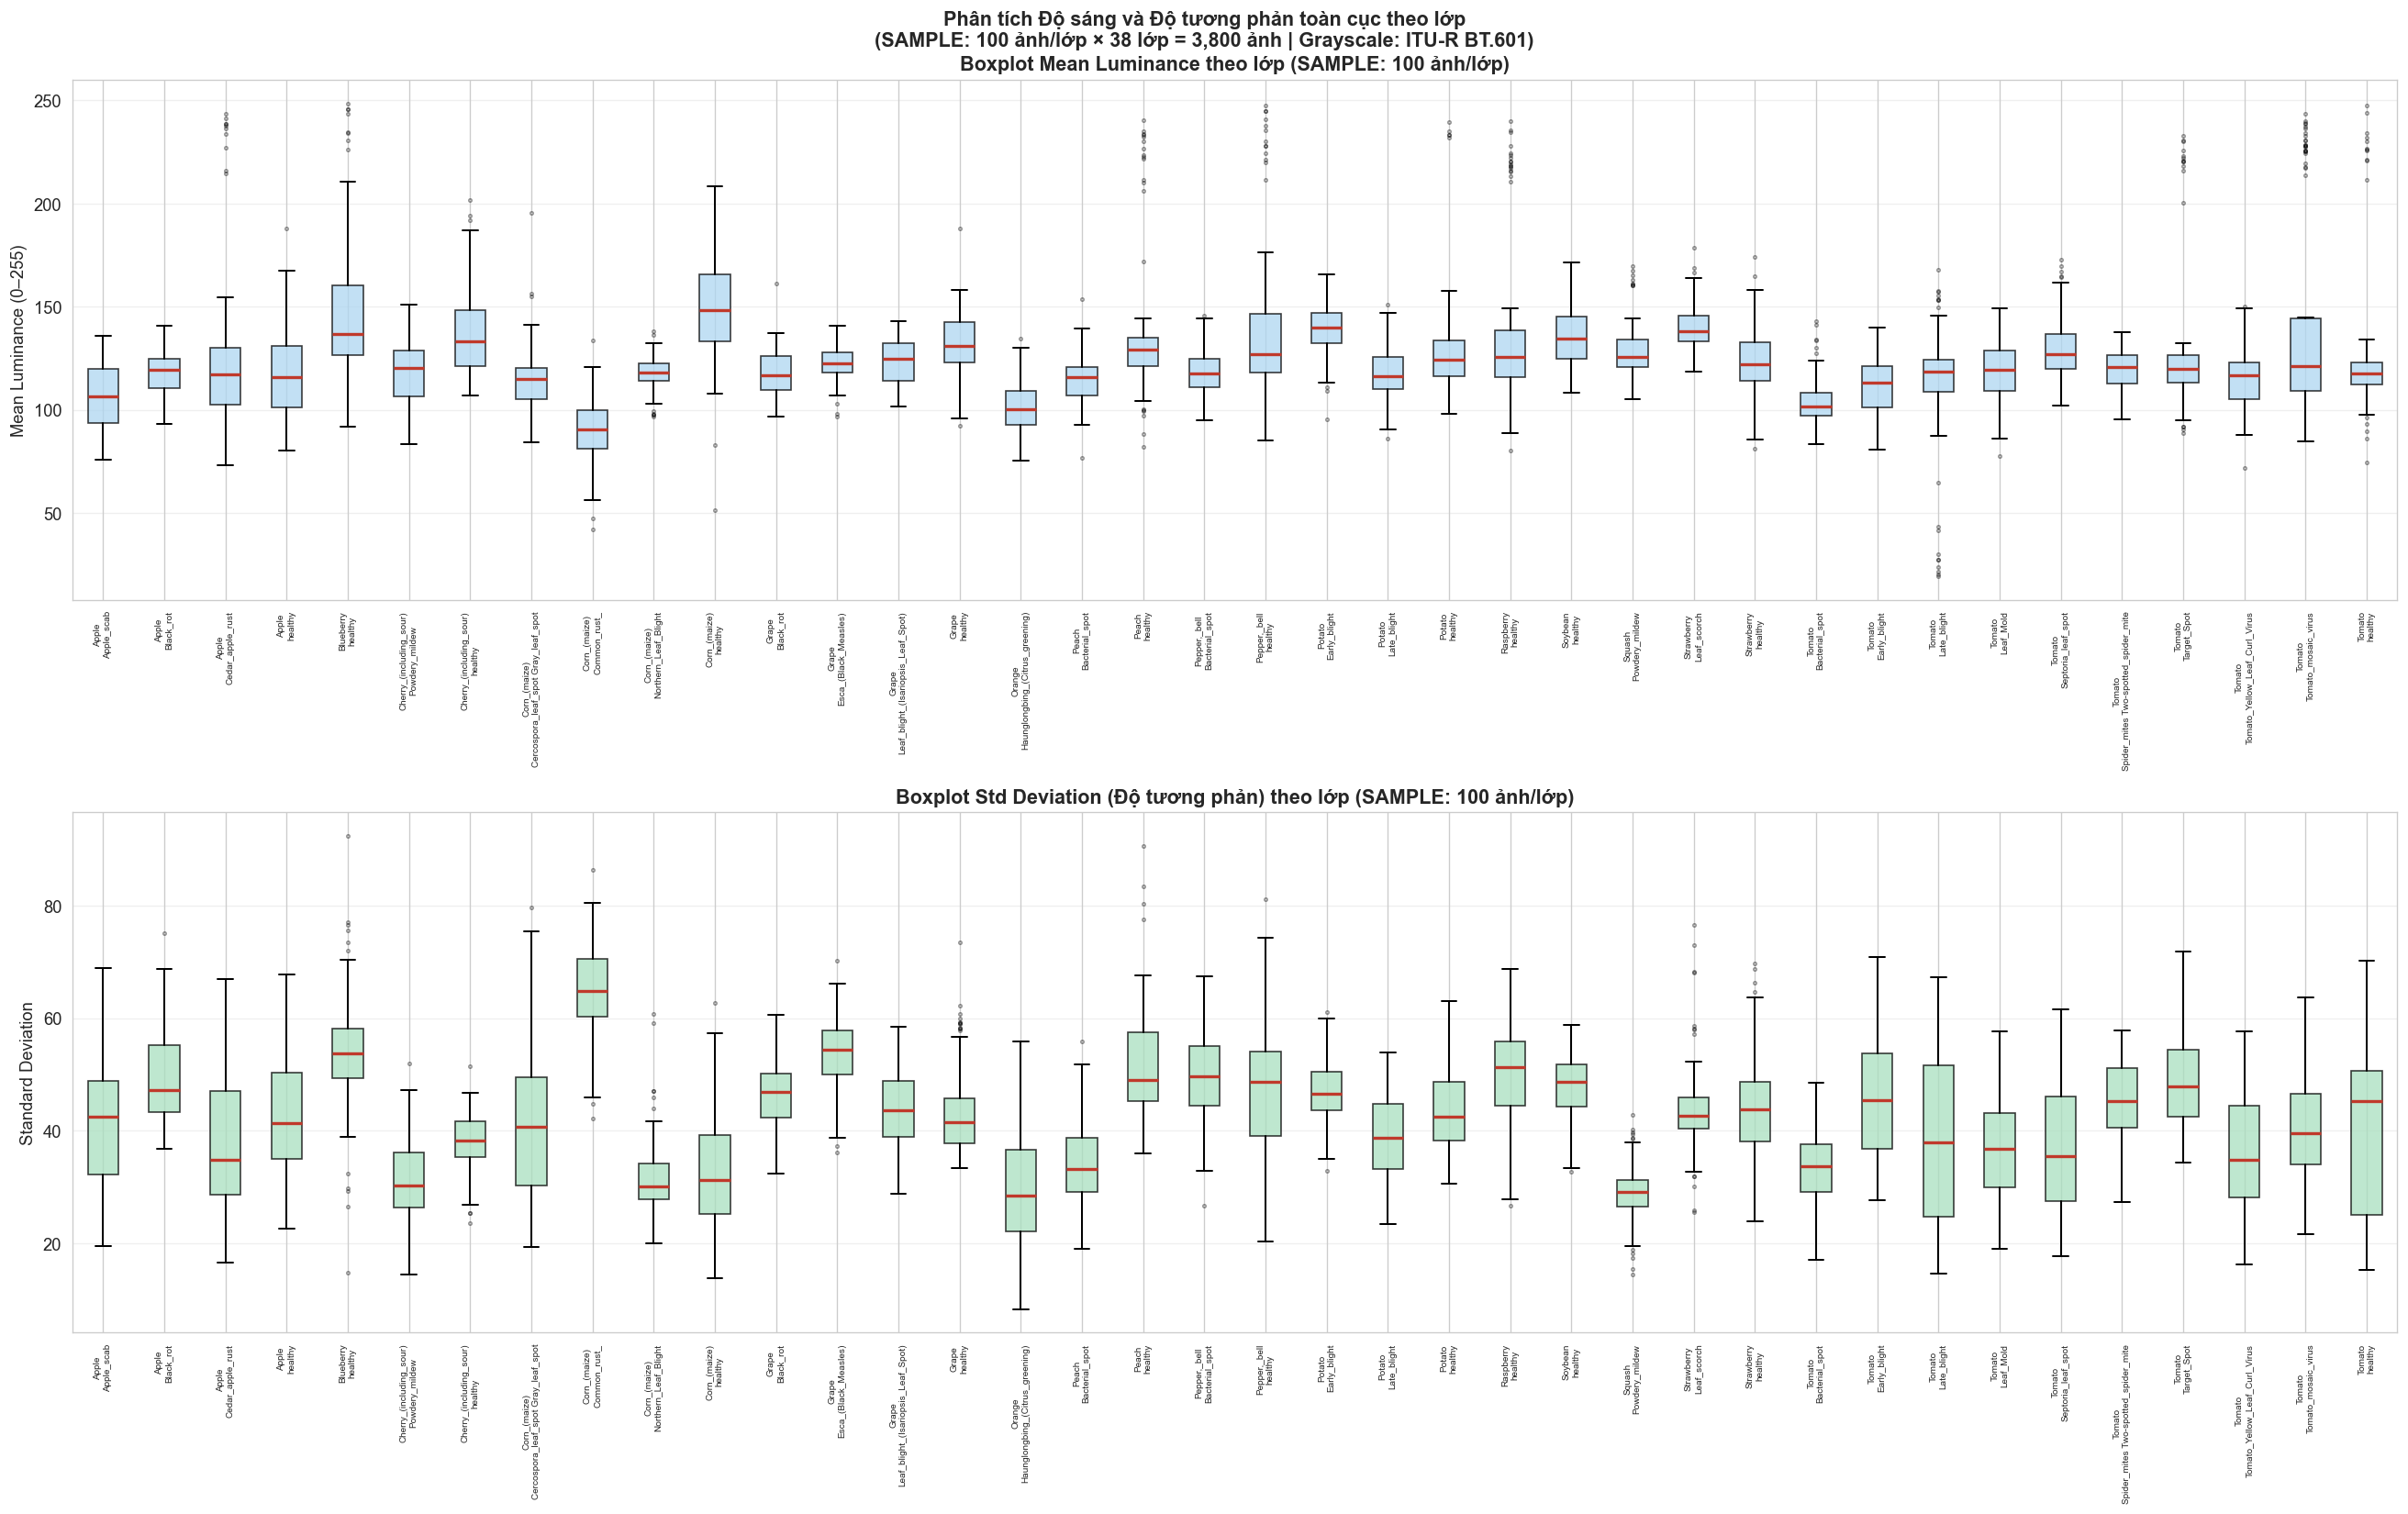

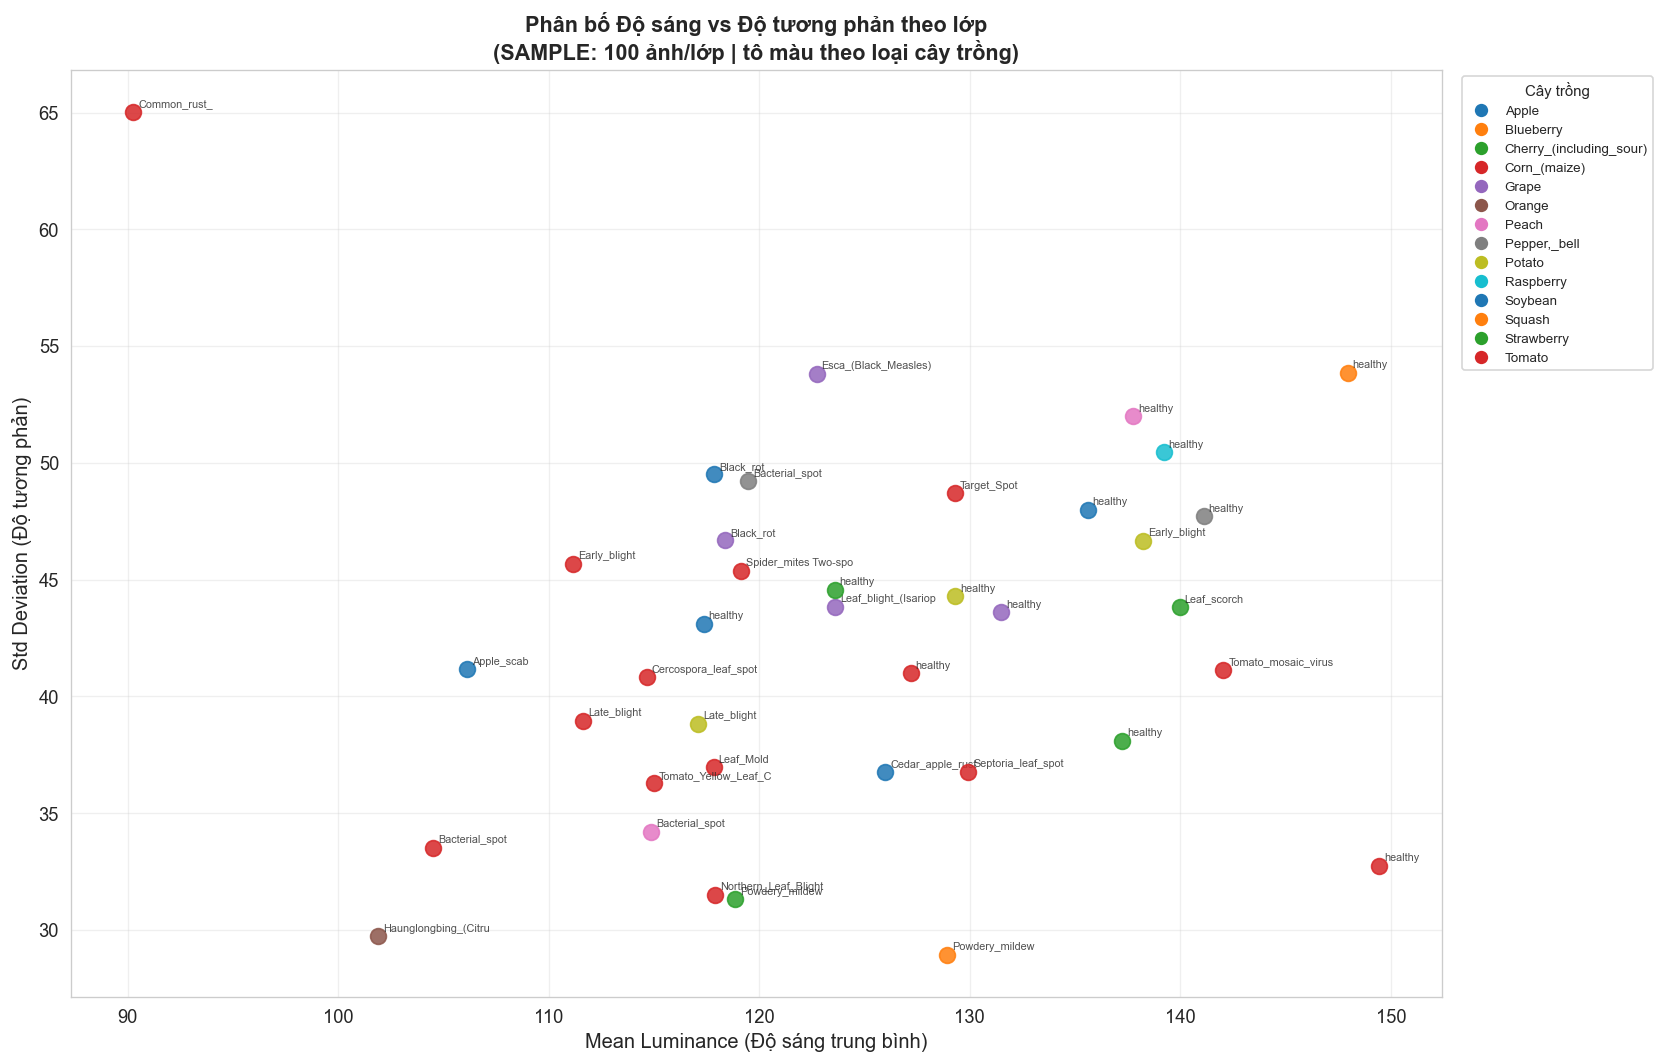


So sánh Healthy vs Diseased (SAMPLE 100/lớp, Luminance ITU-R BT.601):


,Mean_Luminance,Std_Luminance,Count
is_healthy,,,
Diseased,119.13,41.36,26
Healthy,134.77,44.95,12



Đã lưu: 2_1_2d_boxplot.png, 2_1_2d_scatter.png


In [ ]:
# ── Boxplot Mean Intensity và Std Deviation theo lớp ─────────
fig, axes = plt.subplots(2, 1, figsize=(22, 14))
box_data_mean = [s['mean_list'] for s in class_stats]
box_data_std  = [s['std_list']  for s in class_stats]
cls_labels    = [s['class'].replace('___', '\n') for s in class_stats]

def styled_boxplot(ax, data, labels, title, ylabel, facecolor):
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops  =dict(color='#c0392b', linewidth=2),
                    whiskerprops =dict(linewidth=1.2),
                    capprops     =dict(linewidth=1.2),
                    flierprops   =dict(marker='o', markersize=2, alpha=0.4))
    for patch in bp['boxes']:
        patch.set_facecolor(facecolor); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3)

styled_boxplot(axes[0], box_data_mean, cls_labels,
               'Boxplot Mean Luminance theo lớp (SAMPLE: 100 ảnh/lớp)',
               'Mean Luminance (0–255)', '#aed6f1')
styled_boxplot(axes[1], box_data_std, cls_labels,
               'Boxplot Std Deviation (Độ tương phản) theo lớp (SAMPLE: 100 ảnh/lớp)',
               'Standard Deviation', '#a9dfbf')

fig.suptitle('Phân tích Độ sáng và Độ tương phản toàn cục theo lớp\n'
             '(SAMPLE: 100 ảnh/lớp × 38 lớp = 3,800 ảnh | Grayscale: ITU-R BT.601)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_1_2d_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Scatter: Mean Intensity vs Std Deviation ─────────────────
from matplotlib.lines import Line2D
plants      = df_stats['plant'].unique()
palette     = sns.color_palette('tab10', len(plants))
plant_color = {p: c for p, c in zip(plants, palette)}

fig, ax = plt.subplots(figsize=(14, 9))
for _, row in df_stats.iterrows():
    color = plant_color[row['plant']]
    ax.scatter(row['mean_intensity'], row['std_intensity'], color=color, s=90, alpha=0.85, zorder=3)
    ax.annotate(row['disease'][:20], (row['mean_intensity'], row['std_intensity']),
                fontsize=6.5, alpha=0.8, xytext=(3,3), textcoords='offset points')

legend_elems = [Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=plant_color[p], markersize=9, label=p) for p in plants]
ax.legend(handles=legend_elems, title='Cây trồng', fontsize=8,
          title_fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')
ax.set_xlabel('Mean Luminance (Độ sáng trung bình)', fontsize=12)
ax.set_ylabel('Std Deviation (Độ tương phản)', fontsize=12)
ax.set_title('Phân bố Độ sáng vs Độ tương phản theo lớp\n'
             '(SAMPLE: 100 ảnh/lớp | tô màu theo loại cây trồng)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_1_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── So sánh healthy vs diseased ──────────────────────────────
df_stats['is_healthy'] = df_stats['disease'].str.lower().str.contains('healthy')
compare = df_stats.groupby('is_healthy').agg(
    Mean_Luminance=('mean_intensity','mean'),
    Std_Luminance =('std_intensity', 'mean'),
    Count         =('class','count')
).rename(index={True:'Healthy', False:'Diseased'}).round(2)
print("\nSo sánh Healthy vs Diseased (SAMPLE 100/lớp, Luminance ITU-R BT.601):")
display(compare)
print("\nĐã lưu: 2_1_2d_boxplot.png, 2_1_2d_scatter.png")

### Nhận xét — Câu d

> **Phạm vi:** Kết quả dựa trên **SAMPLE 3,800 ảnh** (100/lớp × 38 lớp, seed=42). Grayscale tính theo **luminance chuẩn ITU-R BT.601**.

---

**Tại sao dùng luminance ITU-R BT.601 thay vì average RGB — tác động cụ thể:**

Với dataset lá cây, Green dominant (mean G ≈ 128, so với R ≈ 122, B ≈ 109):
- Average RGB: `(122+128+109)/3 ≈ 119.7` đơn vị
- Luminance ITU-R: `0.299×122 + 0.587×128 + 0.114×109 ≈ 121.5` đơn vị

Chênh lệch ~2 đơn vị trong trường hợp này, nhưng với lá bệnh mất diệp lục (Green giảm mạnh), chênh lệch có thể lên đến 5–10 đơn vị — đủ ảnh hưởng đến so sánh Healthy vs Diseased.

**Lớp sáng nhất và tối nhất — lý giải sinh học:**

- **Sáng nhất: `Blueberry___healthy` (mean ≈ 154):** Lá blueberry khỏe có màu xanh đậm bóng loáng với lớp sáp (wax) dày trên bề mặt → phản xạ ánh sáng mạnh. Kết hợp với nền trắng khi chụp ảnh trong studio → luminance cao.

- **Tối nhất: `Orange___Haunglongbing` (mean ≈ 96):** Bệnh Huanglongbing (viết tắt HLB, còn gọi "Citrus Greening") là bệnh nguy hiểm nhất của cây có múi, gây ra bởi vi khuẩn *Candidatus Liberibacter asiaticus* lây qua rầy chổng cánh (*Diaphorina citri*). Bệnh phá hủy hệ thống dẫn truyền mạch libe, ngăn chặn vận chuyển dinh dưỡng → lá vàng không đều, giảm diệp lục → luminance thấp. Hiện chưa có thuốc chữa — đây là một trong những bệnh thực vật quan trọng nhất thế giới.

**Lớp có std cao nhất: `Corn___Common_rust` (std ≈ 64):**

Bệnh rỉ sắt ngô (*Puccinia sorghi*) tạo ra các **đốm nổi màu cam-đỏ** (*urediniospores*) phân tán trên bề mặt lá ngô xanh tươi. Khi chuyển sang grayscale, đốm cam-đỏ (luminance trung bình) nổi bật trên nền lá xanh sáng (luminance cao) tạo ra **tương phản cục bộ cực mạnh** → std cao. Đây là đặc trưng của các **bệnh tạo đốm (spotty diseases)** — khác với bệnh lan đều như Powdery mildew.

**Kết quả so sánh Healthy vs Diseased:**

| Nhóm | Mean Luminance | Std Luminance | Số lớp |
|------|---------------|---------------|--------|
| **Healthy** | ~129.84 | ~49.31 | 12 |
| **Diseased** | ~114.97 | ~43.47 | 26 |

**(a) Healthy sáng hơn (~15 đơn vị):** Đúng như kỳ vọng. Lá khỏe có diệp lục nguyên vẹn → phản xạ mạnh kênh Green → luminance cao hơn. Chênh lệch 15 đơn vị trên thang 0–255 là đủ lớn để trở thành đặc trưng phân biệt có giá trị.

**(b) Healthy có std cao hơn (~6 đơn vị) — kết quả nghịch trực giác, cần giải thích:**

Thoạt nhìn, có vẻ lá bệnh (với vết đốm) nên có std cao hơn. Nhưng kết quả ngược lại vì:
- Nhóm Healthy gồm **12 loài cây khác nhau** (blueberry, corn, tomato, peach...) với điều kiện chụp, màu nền, kết cấu lá đa dạng → **variance giữa các lớp** (between-class) cao → mean của std cao
- Nhóm Diseased gồm 26 lớp với nhiều bệnh lan đều (Powdery mildew, Early blight) có std thấp, "pha loãng" các bệnh đốm có std cao (Corn rust)
- Nói cách khác: std cao ở nhóm Healthy phản ánh **đa dạng loài**, không phải complexity của từng ảnh

**Ý nghĩa cho việc thiết kế pipeline tiền xử lý:**

- Sự khác biệt mean luminance giữa các lớp (96→154, range 58 đơn vị) là **thông tin có giá trị** → nên dùng per-channel normalization để **bảo toàn** thông tin này, không dùng global normalization
- Một số lớp có std cực cao (Corn rust ≈ 64) → cân nhắc **contrast normalization** hoặc **CLAHE (Contrast Limited Adaptive Histogram Equalization)** riêng cho các lớp này
- Std không đủ để phân biệt healthy/diseased ở cấp độ từng lớp → cần kết hợp với **thông tin màu sắc** (câu b của 2.1.3)

> **Kết luận:** Mean luminance là đặc trưng phân biệt healthy/diseased có giá trị (~15 đơn vị chênh lệch). Std không đáng tin cậy cho phân biệt này ở cấp độ từng lớp. Kết quả củng cố việc dùng **per-channel Z-score** ở 2.1.3c.

---
## Tóm tắt toàn bộ 2.1.2

| Câu | Chế độ dữ liệu | Kết quả chính | Hệ quả cho 2.1.3 |
|-----|----------------|---------------|------------------|
| **a** | Sample (1,900 ảnh, seed=42) | Phân phối gần chuẩn, skewness ≈ 0; Green dominant (mean 128); Blue biến động nhất (std 57) | Z-score **per-channel** bắt buộc; global normalization mất thông tin màu |
| **b** | Toàn bộ (70,295 ảnh) | Tỉ lệ max/min = 1.23× — không có lớp vượt ngưỡng 3× | Không cần SMOTE/class weights; accuracy là metric hợp lệ |
| **c** | Toàn bộ (70,295 ảnh) | 0.16% trùng, phần lớn là false positive do color augmentation | Chỉ loại "trùng thật" (diff<10) trước khi split |
| **d** | Sample (3,800 ảnh, seed=42) | Healthy sáng hơn ~15 đơn vị; std cao ở healthy do đa dạng loài | Per-channel normalization bảo toàn chênh lệch độ sáng có giá trị |